# Spatial Aggregation — Feasibility Study

Exploratory notebook (throwaway code). Question: does "everything to `distrito` (96)" work with the data
we have, and which route wins per source? Spec:
`docs/specs/2026-09-07-spatial-aggregation.md`.
Strategy note: `obsidian-vault/09 - Spatial Aggregation.md`.

Findings are summarised in the last cell.

> Environment note: `geopandas` / `shapely` / `scipy` were installed ad hoc for this
> study (Python 3.14, no conda). They are already listed in `requirements.txt` /
> `environment.yml` for when the pipeline is promoted to `src/`.

In [1]:
import warnings, zipfile, unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RAW = Path("../data/raw")
EXT = Path("../data/external"); EXT.mkdir(parents=True, exist_ok=True)
INT = Path("../data/interim"); INT.mkdir(parents=True, exist_ok=True)

def norm(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    return " ".join(s.upper().split())

## Step 0 — Boundaries: the 96 distritos

Source: GeoSampa WFS layer `geoportal:distrito_municipal`. Cached to
`data/external/` on first run.

96 distritos | geometry valid: True


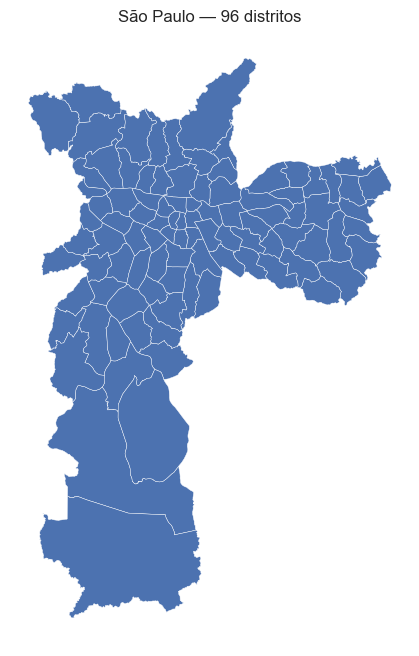

In [2]:
DIST_FILE = EXT / "distrito_municipal.geojson"
if not DIST_FILE.exists():
    url = "http://wfs.geosampa.prefeitura.sp.gov.br/geoserver/ows"
    params = {"service": "WFS", "version": "2.0.0", "request": "GetFeature",
              "typeNames": "geoportal:distrito_municipal",
              "outputFormat": "application/json", "srsName": "EPSG:4326"}
    DIST_FILE.write_bytes(requests.get(url, params=params, timeout=120).content)

dist = gpd.read_file(DIST_FILE)[["nm_distrito_municipal", "qt_area_metro", "geometry"]]
dist["geometry"] = dist.geometry.make_valid()
dist["distrito"] = dist["nm_distrito_municipal"].map(norm)
D = sorted(dist["distrito"])
print(f"{len(dist)} distritos | geometry valid: {dist.is_valid.all()}")
dist.plot(edgecolor="white", linewidth=0.3, figsize=(8, 8)); plt.axis("off"); plt.title("São Paulo — 96 distritos"); plt.show()

## Step 1 — Airbnb → distrito

Candidate routes: (a) trust `neighbourhood_cleansed`; (b) point-in-polygon on
`latitude`/`longitude`. Compare them.

In [3]:
li = pd.read_csv(RAW / "Airbnb" / "listings.csv", low_memory=False,
                 usecols=["id", "neighbourhood_cleansed", "latitude", "longitude"])
li["nc_key"] = li["neighbourhood_cleansed"].map(norm)

pts = gpd.GeoDataFrame(li, geometry=gpd.points_from_xy(li.longitude, li.latitude), crs="EPSG:4326")
pip = gpd.sjoin(pts, dist[["distrito", "geometry"]], how="left", predicate="within")
pip = pip[~pip.index.duplicated()]

outside = pip["distrito"].isna().sum()
unknown_labels = sorted(set(li["nc_key"]) - set(D))
mism = (pip["nc_key"] != pip["distrito"]) & pip["distrito"].notna()
print(f"listings: {len(li)}")
print(f"neighbourhood_cleansed values not in the 96-distrito set: {unknown_labels}")
print(f"points falling outside every distrito: {outside}")
print(f"neighbourhood_cleansed disagrees with point-in-polygon: {mism.sum()} ({mism.mean()*100:.2f}%)")

listings: 42354
neighbourhood_cleansed values not in the 96-distrito set: []
points falling outside every distrito: 0
neighbourhood_cleansed disagrees with point-in-polygon: 0 (0.00%)


**Verdict — Step 1:** `neighbourhood_cleansed` already *is* the point-in-polygon result
against these exact boundaries (0 disagreements, 0 points outside). Inside Airbnb did
the join for us. **Route: use `neighbourhood_cleansed` directly; point-in-polygon is a
one-off validation, not a pipeline step.**

## Step 2 — IPTU-SP → distrito

IPTU has no coordinates. Candidate routes:
- **(A) `bairro`** — free-text field, fuzzy-match to distrito names.
- **(B) `cep`** — join via a CEP→distrito table.
- **(C) `numero_contribuinte` (SQL)** — first 6 digits = fiscal sector + block;
  join to the GeoSampa `quadra_fiscal` polygons, then point-in-polygon to distrito.

In [4]:
it = pd.read_csv(zipfile.ZipFile(RAW / "IPTU-SP" / "iptu_2025.zip").open("iptu_2025.csv"),
                 low_memory=False,
                 usecols=["numero_contribuinte", "bairro", "cep", "valor_construcao",
                          "area_construida", "finalidade_imovel"],
                 dtype={"numero_contribuinte": str, "cep": str})
print(f"IPTU rows: {len(it):,}")

# Route A — bairro
bkey = it["bairro"].dropna().map(norm)
exact_rows = bkey.isin(set(D)).mean()
print(f"Route A (bairro): {it['bairro'].nunique():,} unique values, "
      f"{bkey.isin(set(D)).sum():,} rows exact-match a distrito name ({exact_rows*100:.1f}%)")
print("  sample bairro values:", sorted(bkey.unique())[:8])

IPTU rows: 3,806,436


Route A (bairro): 96,122 unique values, 537,527 rows exact-match a distrito name (14.1%)


  sample bairro values: ['', '&', '& 1 ARMARIO', '& 2 VGS', '& CESAR', '& M PAULISTA', '& MIGUEL PAULISTA', '& ORATORIO N 23']


In [5]:
# Route C — numero_contribuinte -> quadra_fiscal -> distrito
QF_FILE = EXT / "quadra_fiscal.gpkg"
if not QF_FILE.exists():
    base = "http://wfs.geosampa.prefeitura.sp.gov.br/geoserver/ows"
    parts, step, i = [], 10000, 0
    while True:
        p = {"service": "WFS", "version": "2.0.0", "request": "GetFeature",
             "typeNames": "geoportal:quadra_fiscal", "outputFormat": "application/json",
             "srsName": "EPSG:4326", "count": str(step), "startIndex": str(i),
             "sortBy": "cd_identificador"}
        g = gpd.read_file(requests.get(base, params=p, timeout=180).content.decode())
        parts.append(g[["cd_setor_fiscal", "cd_quadra_fiscal", "geometry"]])
        if len(g) < step:
            break
        i += step
    qf = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs="EPSG:4326")
    qf["geometry"] = qf.geometry.make_valid()
    qf = qf[qf.geometry.notna() & ~qf.geometry.is_empty].copy()
    qf["sq"] = (qf["cd_setor_fiscal"].astype(str).str.zfill(3)
                + qf["cd_quadra_fiscal"].astype(str).str.zfill(3))
    qf.to_file(QF_FILE, driver="GPKG")
else:
    qf = gpd.read_file(QF_FILE)

Q2D_FILE = EXT / "quadra_to_distrito.csv"
if not Q2D_FILE.exists():
    cen = gpd.GeoDataFrame(qf[["sq"]], geometry=qf.geometry.representative_point(), crs="EPSG:4326")
    jj = gpd.sjoin(cen, dist[["distrito", "geometry"]], how="left", predicate="within")
    (jj.dropna(subset=["distrito"]).groupby("sq")["distrito"]
       .agg(lambda s: s.mode().iat[0]).to_frame().to_csv(Q2D_FILE))
q2d = pd.read_csv(Q2D_FILE, dtype={"sq": str}).set_index("sq")["distrito"]

it["sq"] = it["numero_contribuinte"].str.zfill(11).str[:6]
it["distrito"] = it["sq"].map(q2d)
print(f"quadra_fiscal polygons: {len(qf):,} | mapped sector+block keys: {len(q2d):,}")
print(f"Route C (SQL): IPTU rows mapped to a distrito: {it['distrito'].notna().mean()*100:.2f}% "
      f"| distritos covered: {it['distrito'].nunique()}/96")

quadra_fiscal polygons: 64,216 | mapped sector+block keys: 47,865


Route C (SQL): IPTU rows mapped to a distrito: 99.94% | distritos covered: 96/96


In [6]:
# Cost signal per distrito (residential only). NOTE: valor_construcao is a *fiscal*
# value, not market price -- the level is not meaningful here, only the join is.
RES = ['Residência', 'Apartamento Em Condomínio',
       'Residência E Outro Uso (Predominância Residencial)',
       'Prédio De Apartamento, Não Em Condomínio, De Uso Exclusivamente Residencial',
       'Flat Residencial Em Condomínio']
itr = it[it["finalidade_imovel"].isin(RES)].copy()
itr["vm2"] = itr["valor_construcao"] / itr["area_construida"].replace(0, np.nan)
itr = itr[(itr["vm2"] > 50) & (itr["vm2"] < 50000)]
cost = itr.groupby("distrito")["vm2"].median().rename("iptu_valor_m2_median").reindex(D)
print(cost.describe().round(1))

count    96.0
mean     61.7
std       7.4
min      51.0
25%      57.0
50%      59.6
75%      65.9
max      93.4
Name: iptu_valor_m2_median, dtype: float64


**Verdict — Step 2:** Route A (`bairro`) is unusable — the field is free text, ~96k
distinct dirty values, ~14% exact match. Route C (`numero_contribuinte` → `quadra_fiscal`
→ distrito) maps **99.94%** of rows and covers all 96 distritos, with **no geocoding**.
**Route: C.** Route B (CEP) was not needed.

Caveat: `valor_construcao` is a fiscal value; the cost *level* needs FipeZAP calibration
later. The study only validates the join.

## Step 3 — Crime (SSP-SP) → distrito

The crime data is reported per **DP** (police precinct); the only location signal is the
neighbourhood name in the `DP` string. Routes: (a) match the DP name to a distrito name;
(b) geocode the DP name and point-in-polygon.

Then compare the two treatments for the granularity mismatch:
- **A** — impute each DP's rate to its distrito.
- **B** — sum DPs that fall in the same distrito.

In [7]:
cr = pd.read_csv("../data/processed/ISP/dados_criminais_sao_paulo_2025.csv")
cr["2025"] = cr["2025"].fillna(0)
cr["bairro"] = cr["DP"].str.split(" - ").str[-1].str.strip()
occ = cr[~cr["NATUREZA2"].str.startswith("Nº DE VÍTIMAS")]
dp_names = sorted(cr["bairro"].dropna().unique())
dp_total = occ.groupby("bairro")["2025"].sum()

exact = sum(norm(b) in set(D) for b in dp_names)
print(f"distinct DPs: {len(dp_names)}")
print(f"Route A (name match): {exact}/{len(dp_names)} DP names are also distrito names")

distinct DPs: 94
Route A (name match): 48/94 DP names are also distrito names


In [8]:
# Route B -- geocode DP names, bounded to the SP bounding box, then point-in-polygon.
XW_FILE = EXT / "dp_to_distrito.csv"
if not XW_FILE.exists():
    import time
    minx, miny, maxx, maxy = dist.total_bounds
    vb = f"{minx},{maxy},{maxx},{miny}"
    H = {"User-Agent": "ssc0957-study/1.0 (academic)"}
    rows = []
    for b in dp_names:
        r = requests.get("https://nominatim.openstreetmap.org/search",
                         params={"q": f"{b}, São Paulo", "format": "json", "limit": 1,
                                 "viewbox": vb, "bounded": 1}, headers=H, timeout=30)
        d = r.json()
        rows.append((b, float(d[0]["lat"]), float(d[0]["lon"])) if d else (b, None, None))
        time.sleep(1.1)
    gg = pd.DataFrame(rows, columns=["bairro", "lat", "lon"])
    sub = gg.dropna()
    gsub = gpd.GeoDataFrame(sub, geometry=gpd.points_from_xy(sub.lon, sub.lat), crs="EPSG:4326")
    j = gpd.sjoin(gsub, dist, how="left", predicate="within")
    gg.merge(j[["bairro", "distrito"]], on="bairro", how="left").to_csv(XW_FILE, index=False)

xw = pd.read_csv(XW_FILE)

# 9 informal names Nominatim could not place inside a distrito -- hand-mapped, FLAGGED for review.
MANUAL = {"Jardim Mirna": "CAMPO GRANDE", "Parque Santo Antônio": "JARDIM SAO LUIS",
          "Parque São Rafael": "SAO RAFAEL", "Vale do Aricanduva": "ARICANDUVA",
          "Vila Alpina": "SAPOPEMBA", "Vila Diva": "ARICANDUVA",
          "Vila Pereira Barreto": "VILA GUILHERME", "Vila Rica": "JARAGUA",
          "Vila Santa Maria": "TREMEMBE"}
xw["source"] = np.where(xw["bairro"].isin(MANUAL), "manual-review", "geocode")
xw["distrito"] = xw.apply(lambda r: MANUAL.get(r["bairro"], r["distrito"]), axis=1)
xw = xw.dropna(subset=["distrito"])
xw["crime"] = xw["bairro"].map(dp_total)

print(f"crosswalk: {len(xw)} DPs -> {xw['distrito'].nunique()} distinct distritos")
print(f"distritos with NO DP mapped: {96 - xw['distrito'].nunique()}")
print(xw["source"].value_counts().to_dict())

crosswalk: 94 DPs -> 71 distinct distritos
distritos with NO DP mapped: 25
{'geocode': 85, 'manual-review': 9}


In [9]:
A = xw.groupby("distrito")["crime"].mean()
B = xw.groupby("distrito")["crime"].sum()
common = A.index.intersection(B.index)
rho = spearmanr(A[common], B[common]).correlation
print(f"treatment A vs B — Spearman rho on the {len(common)} covered distritos: {rho:.3f}")

moved = (B[common] - A[common]).abs().sort_values(ascending=False).head(8)
print("\ndistritos where A and B disagree most (multiple DPs land in them):")
print(moved.round(0))

crime = A.rename("crime_dp_mean").reindex(D)
print(f"\ndistritos with a crime value: {crime.notna().sum()}/96")

treatment A vs B — Spearman rho on the 71 covered distritos: 0.791

distritos where A and B disagree most (multiple DPs land in them):
distrito
JARDIM SAO LUIS    8926.0
CIDADE ADEMAR      8258.0
IPIRANGA           8239.0
SANTA CECILIA      8049.0
ITAIM BIBI         6844.0
VILA MARIANA       6485.0
SANTANA            5738.0
TATUAPE            5465.0
Name: crime, dtype: float64

distritos with a crime value: 71/96


**Verdict — Step 3:** DP labels are **not** a partition of the distritos. Name-matching
covers ~half; bounded geocoding gets ~85/94; 9 informal names need hand-mapping. Even
then only ~71/96 distritos receive a DP, and **treatment A vs B only correlate at
ρ≈0.79** — the choice materially changes the crime ranking.

**Route: a hand-built, reviewed `dp,distrito` lookup is unavoidable** (geocoding is a
first draft, not the answer). The ~25 distritos with no DP need crime imputed from a
neighbour or from the subprefectura. Pick treatment A vs B during Phase 2 against the
representativeness check.

## Step 4 — POI / tourist appeal (OSM Overpass, placeholder for Google Places)

In [10]:
POI_FILE = EXT / "poi_by_distrito.csv"
if not POI_FILE.exists():
    minx, miny, maxx, maxy = dist.total_bounds
    q = f'''[out:json][timeout:240];
    (
     node["tourism"~"attraction|museum|gallery|viewpoint|artwork|theme_park|zoo"]({miny},{minx},{maxy},{maxx});
     node["historic"]({miny},{minx},{maxy},{maxx});
     node["leisure"~"park|garden"]({miny},{minx},{maxy},{maxx});
    );
    out center;'''
    eps = ["https://overpass-api.de/api/interpreter",
           "https://overpass.kumi.systems/api/interpreter",
           "https://overpass.private.coffee/api/interpreter"]
    import time
    data = None
    for k in range(6):
        r = requests.post(eps[k % len(eps)], data={"data": q}, timeout=250,
                          headers={"User-Agent": "ssc0957-study/1.0"})
        if r.status_code == 200 and r.text.strip().startswith("{"):
            data = r.json(); break
        time.sleep(20)
    els = data["elements"]
    p = pd.DataFrame([{"lat": e.get("lat") or e.get("center", {}).get("lat"),
                       "lon": e.get("lon") or e.get("center", {}).get("lon")}
                      for e in els]).dropna()
    gp = gpd.GeoDataFrame(p, geometry=gpd.points_from_xy(p.lon, p.lat), crs="EPSG:4326")
    jj = gpd.sjoin(gp, dist[["distrito", "geometry"]], how="inner", predicate="within")
    cnt = jj.groupby("distrito").size().rename("poi_n")
    r = dist[["distrito", "qt_area_metro"]].merge(cnt, on="distrito", how="left").fillna({"poi_n": 0})
    r["poi_per_km2"] = r["poi_n"] / (r["qt_area_metro"] / 1e6)
    r.to_csv(POI_FILE, index=False)

poi = pd.read_csv(POI_FILE).set_index("distrito")["poi_per_km2"].reindex(D)
print(f"distritos with >=1 OSM POI: {(poi > 0).sum()}/96")
print(poi.sort_values(ascending=False).head(6).round(1))

distritos with >=1 OSM POI: 69/96
distrito
REPUBLICA     26.7
SE            17.3
LIBERDADE     12.6
IPIRANGA       9.5
BELA VISTA     6.3
CONSOLACAO     6.0
Name: poi_per_km2, dtype: float64


**Verdict — Step 4:** OSM gives 871 POIs, 69/96 distritos non-zero, heavily
central-biased — 27 peripheral distritos empty. Usable as a rough placeholder only.
**Google Places is required** for a real tourist-appeal signal (`GOOGLE_PLACES_API_KEY`
still not wired up).

## Step 5 — Assembled `distrito` feature table

In [11]:
rev = (li.assign(distrito=li["nc_key"])
         .groupby("distrito").size().rename("airbnb_listings").reindex(D))
est_rev = (pd.read_csv(RAW / "Airbnb" / "listings.csv", low_memory=False,
                       usecols=["neighbourhood_cleansed", "estimated_revenue_l365d"])
             .assign(distrito=lambda d: d["neighbourhood_cleansed"].map(norm))
             .groupby("distrito")["estimated_revenue_l365d"].median()
             .rename("est_revenue_median").reindex(D))

table = pd.concat([rev, est_rev, cost, crime, poi], axis=1)
table.to_csv(INT / "distrito_features_study.csv")
print("shape:", table.shape)
print("nulls per column:\n", table.isna().sum())
table.head(12).round(1)

shape: (96, 5)
nulls per column:
 airbnb_listings          0
est_revenue_median       0
iptu_valor_m2_median     0
crime_dp_mean           25
poi_per_km2              0
dtype: int64


,airbnb_listings,est_revenue_median,iptu_valor_m2_median,crime_dp_mean,poi_per_km2
distrito,,,,,
AGUA RASA,226,15990.0,55.3,3356.0,0.0
ALTO DE PINHEIROS,266,8424.0,65.9,NaN,0.5
ANHANGUERA,30,0.0,66.6,NaN,0.1
ARICANDUVA,18,1383.5,57.0,2685.0,0.0
ARTUR ALVIM,42,0.0,52.1,3866.5,0.0
BARRA FUNDA,567,25284.0,55.3,NaN,3.2
BELA VISTA,2459,16410.0,76.2,NaN,6.3
BELEM,308,15098.0,58.4,2259.0,0.5
BOM RETIRO,247,15744.0,62.3,4261.0,1.4


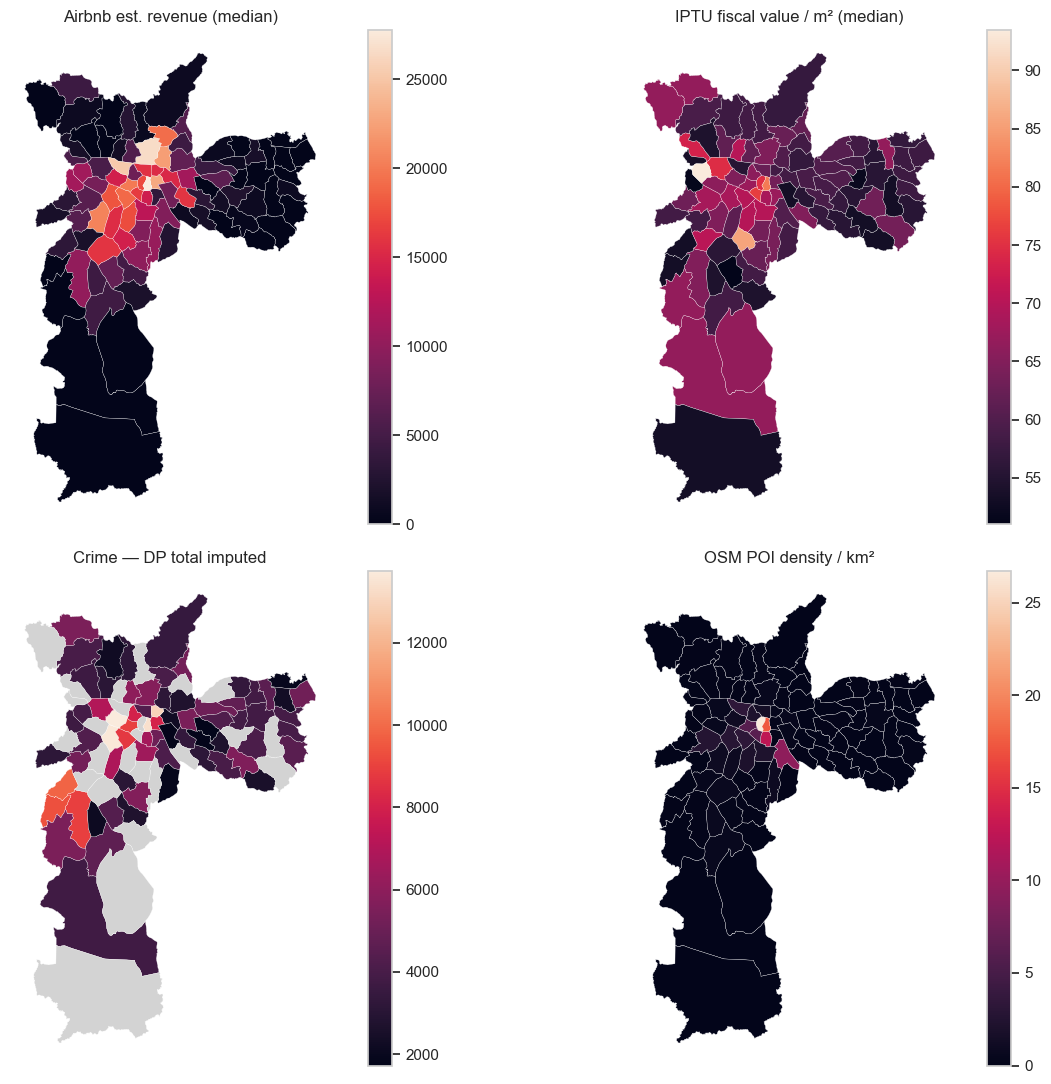

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, col, ttl in zip(axes.flat,
        ["est_revenue_median", "iptu_valor_m2_median", "crime_dp_mean", "poi_per_km2"],
        ["Airbnb est. revenue (median)", "IPTU fiscal value / m² (median)",
         "Crime — DP total imputed", "OSM POI density / km²"]):
    dist.merge(table[col], left_on="distrito", right_index=True).plot(
        column=col, ax=ax, legend=True, edgecolor="white", linewidth=0.2,
        missing_kwds={"color": "lightgrey", "label": "no data"})
    ax.set_title(ttl); ax.axis("off")
plt.tight_layout(); plt.show()

## Findings

| Join | Winning route | Coverage | Confidence |
|---|---|---|---|
| **Airbnb → distrito** | `neighbourhood_cleansed` as-is (PIP only to validate) | 100% | high — it *is* the PIP result |
| **IPTU → distrito** | `numero_contribuinte`[:6] → `quadra_fiscal` → PIP | 99.94%, 96/96 | high — no geocoding |
| **Crime → distrito** | hand-built + reviewed `dp,distrito` lookup | ~71/96 distritos; ~25 need imputation | **low** — geocoding is a draft; A vs B ρ≈0.79 |
| **POI → distrito** | OSM Overpass placeholder | 69/96 non-zero, central-biased | low — needs Google Places |

**Recommended pipeline unit: distrito. Confirmed workable for cost + revenue.**

**Open gaps (carried to `09 - Spatial Aggregation.md`):**
1. Crime crosswalk needs manual construction + review; decide imputation for the ~25
   DP-less distritos; decide treatment A vs B in Phase 2.
2. Google Places not collected — OSM is a stopgap.
3. IPTU `valor_construcao` is a fiscal value; cost level needs FipeZAP calibration.
4. Population by distrito (SEADE / IBGE 2022) needed to turn crime counts into rates.
5. `quadra_fiscal` centroid-in-distrito assignment: a handful of blocks straddle
   boundaries — acceptable at this grain, revisit only if Phase 2 flags it.

**Artifacts written** (all git-ignored under `data/`):
`data/external/{distrito_municipal.geojson, quadra_fiscal.gpkg, quadra_to_distrito.csv,
dp_to_distrito.csv, poi_by_distrito.csv}`, `data/interim/distrito_features_study.csv`.